<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Task 4</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
    <b>Instruction:</b> Train a linear regression model in PyTorch using a regression dataset.
</p>

<ul>
    <li>Criterion: MSE Loss</li>
    <li>Fully Connected Layers x 2</li>
    <li>Batch Size: 8</li>
    <li>Optimizer: SGD</li>
    <li>Epoch: 1000</li>
</ul>
</div>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The sample implementation earlier in this notebook used a single <tt>nn.Linear</tt> layer, which is really
just plain linear regression written with PyTorch's tensor machinery. This task asks for two fully connected
layers instead, so the model gets a hidden layer in between the input and the output. Stacking a second layer
on top of a regression problem does not automatically make it "deep learning" in any meaningful sense here, but
it lets us practice building a small <tt>nn.Module</tt>, wiring up a <tt>DataLoader</tt> with a specific batch
size, and running a longer training loop than the 100-epoch example above.
</p>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
To keep this self-contained and reproducible, the dataset used below is the diabetes dataset that ships with
<tt>sklearn.datasets</tt>. It has ten numeric features per patient (age, sex, BMI, average blood pressure, and
six blood serum measurements) and one continuous target: a quantitative measure of how much the disease
progressed a year after these baseline measurements were taken. It is a proper regression dataset rather than
the 15-row toy example used earlier, which makes batching, scaling, and a train/test split actually matter, and
since it ships with scikit-learn there is no external download involved.
</p>

<h4 style="font-family: Times New Roman"><strong>1. Imports and Setup</strong></h4>

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


<h4 style="font-family: Times New Roman"><strong>2. Loading and Preparing the Data</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
<tt>load_diabetes</tt> returns the feature matrix <tt>X</tt> (10 columns) and the target vector <tt>y</tt> (the
disease progression score). Before doing anything else, the data is split into a training set and a test set,
so that the model's performance can be checked on rows it never trained on.
</p>

In [2]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target.reshape(-1, 1)

print("Feature matrix:", X.shape)
print("Target vector: ", y.shape)
print("Feature names: ", diabetes.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain rows:", X_train.shape[0])
print("Test rows: ", X_test.shape[0])

Feature matrix: (442, 10)
Target vector:  (442, 1)
Feature names:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Train rows: 353
Test rows:  89


<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The features here are already fairly small numbers (scikit-learn's version of this dataset is pre-centered),
but they are not all on the same scale. Feeding that straight into a network trained with plain SGD makes the loss surface badly
conditioned and slows convergence, so both the inputs and the target are standardized (zero mean, unit
variance) using statistics from the training set only. The scaler is fit on the training split and then
applied to the test split, so no information from the test set leaks into training.
</p>

In [3]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Convert everything to float32 tensors, which is what PyTorch expects by default
X_train_t = torch.from_numpy(X_train_scaled).float()
y_train_t = torch.from_numpy(y_train_scaled).float()
X_test_t = torch.from_numpy(X_test_scaled).float()
y_test_t = torch.from_numpy(y_test_scaled).float()

print(X_train_t.shape, y_train_t.shape)
print(X_test_t.shape, y_test_t.shape)

torch.Size([353, 10]) torch.Size([353, 1])
torch.Size([89, 10]) torch.Size([89, 1])


<h4 style="font-family: Times New Roman"><strong>3. Dataset and DataLoader</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Same pattern as the sample implementation above: wrap the tensors in a <tt>TensorDataset</tt> and hand that to
a <tt>DataLoader</tt>. The task specifies a batch size of 8, and shuffling is left on so the model does not see
the training rows in the same order every epoch.
</p>

In [4]:
train_ds = TensorDataset(X_train_t, y_train_t)

batch_size = 8
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# Quick sanity check on one batch
xb, yb = next(iter(train_dl))
print("Batch inputs: ", xb.shape)
print("Batch targets:", yb.shape)

Batch inputs:  torch.Size([8, 10])
Batch targets: torch.Size([8, 1])


<h4 style="font-family: Times New Roman"><strong>4. Model &mdash; Two Fully Connected Layers</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Instead of defining the model as a single <tt>nn.Linear</tt> call the way the sample implementation did, it is
written here as a small <tt>nn.Module</tt> subclass with two fully connected layers:
</p>
<ul style="font-family:Times New Roman; font-size:15px">
    <li><tt>fc1</tt>: 10 input features &rarr; 16 hidden units, followed by a ReLU</li>
    <li><tt>fc2</tt>: 16 hidden units &rarr; 1 output (the predicted, scaled progression score)</li>
</ul>
<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The ReLU between the two layers is what actually gives the second layer something to do &mdash; without it,
two stacked linear layers collapse mathematically into one linear layer, which would defeat the point of
having two of them.
</p>

In [5]:
class RegressionNet(nn.Module):
    def __init__(self, in_features, hidden_units=16):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_units, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = RegressionNet(in_features=X_train_t.shape[1], hidden_units=16).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTrainable parameters:", n_params)

RegressionNet(
  (fc1): Linear(in_features=10, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Trainable parameters: 193


<h4 style="font-family: Times New Roman"><strong>5. Loss Function and Optimizer</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
As required, the criterion is <tt>nn.MSELoss</tt> and the optimizer is plain <tt>optim.SGD</tt>. A small amount
of momentum (0.9) is kept, matching the sample implementation earlier in the notebook, since vanilla SGD with a
learning rate high enough to converge in 1000 epochs tends to oscillate on this dataset.
</p>

In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

<h4 style="font-family: Times New Roman"><strong>6. Training</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The training function follows the same four steps as the sample implementation &mdash; predict, compute loss,
backpropagate, update &mdash; run for every batch in every epoch. The average loss per epoch is stored so it
can be plotted afterward, and progress is printed every 100 epochs to keep the output readable across 1000
epochs.
</p>

In [7]:
def fit(num_epochs, model, loss_fn, optimizer, train_dl):
    history = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        n_batches = 0

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)

            # 1. Predict
            pred = model(xb)

            # 2. Calculate loss
            loss = loss_fn(pred, yb)

            # 3. Calculate gradients
            optimizer.zero_grad()
            loss.backward()

            # 4. Update parameters
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        history.append(avg_loss)

        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Avg. Batch Loss: {avg_loss:.4f}")

    return history

history = fit(1000, model, criterion, optimizer, train_dl)

Epoch [100/1000], Avg. Batch Loss: 0.3879


Epoch [200/1000], Avg. Batch Loss: 0.3301


Epoch [300/1000], Avg. Batch Loss: 0.3189


Epoch [400/1000], Avg. Batch Loss: 0.3337


Epoch [500/1000], Avg. Batch Loss: 0.2753


Epoch [600/1000], Avg. Batch Loss: 0.2607


Epoch [700/1000], Avg. Batch Loss: 0.2623


Epoch [800/1000], Avg. Batch Loss: 0.2863


Epoch [900/1000], Avg. Batch Loss: 0.2824


Epoch [1000/1000], Avg. Batch Loss: 0.3164


<h4 style="font-family: Times New Roman"><strong>7. Loss Curve</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Plotting the average per-epoch loss shows whether training actually converged or just wandered around. A
healthy curve here drops quickly in the first stretch of epochs and then flattens out.
</p>

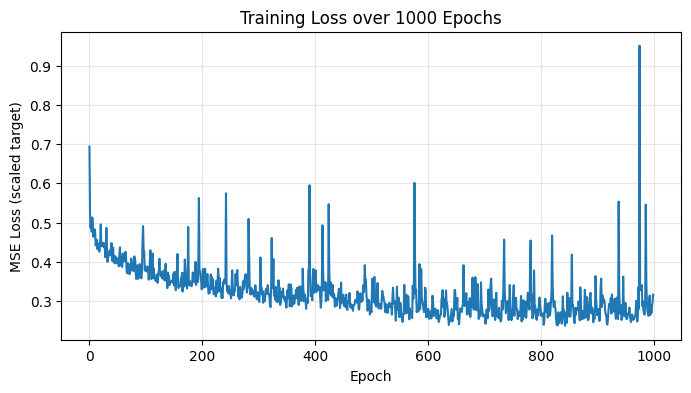

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title("Training Loss over 1000 Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled target)")
plt.grid(alpha=0.3)
plt.show()

<h4 style="font-family: Times New Roman"><strong>8. Evaluation on the Test Set</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The model has not seen the test rows during training, so the loss on that set is a more honest measure of how
well it generalizes than the training loss. Predictions are also converted back to the original target scale
with <tt>y_scaler.inverse_transform</tt>, since the raw scaled numbers on their own are not very interpretable.
<tt>model.eval()</tt> and <tt>torch.no_grad()</tt> are used here since gradients are not needed for inference.
</p>

In [9]:
model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test_t.to(device)).cpu()
    test_loss = criterion(test_preds_scaled, y_test_t)

print(f"Test MSE (scaled target): {test_loss.item():.4f}")

# Undo the scaling to compare predictions against actual progression score
test_preds = y_scaler.inverse_transform(test_preds_scaled.numpy())
test_actual = y_scaler.inverse_transform(y_test_t.numpy())

mae = np.mean(np.abs(test_preds - test_actual))
rmse = np.sqrt(np.mean((test_preds - test_actual) ** 2))

print(f"Test MAE:  {mae:.4f}  (disease progression score)")
print(f"Test RMSE: {rmse:.4f}  (disease progression score)")

Test MSE (scaled target): 0.7307
Test MAE:  49.5835  (disease progression score)
Test RMSE: 66.6341  (disease progression score)


<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
As a sanity check, here are the first ten predictions next to the actual progression scores for those same
test rows.
</p>

In [10]:
for i in range(10):
    print(f"Predicted: {test_preds[i, 0]:6.3f}   Actual: {test_actual[i, 0]:6.3f}")

Predicted: 128.635   Actual: 219.000
Predicted: 87.053   Actual: 70.000
Predicted: 213.010   Actual: 202.000
Predicted: 428.222   Actual: 230.000
Predicted: 125.471   Actual: 111.000
Predicted: 81.653   Actual: 84.000
Predicted: 260.404   Actual: 242.000
Predicted: 222.720   Actual: 272.000
Predicted: 137.201   Actual: 94.000
Predicted: 102.850   Actual: 96.000


<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
A scatter plot of predicted versus actual values gives a quicker read on overall fit than scrolling through
numbers. Points sitting close to the diagonal line mean the prediction was close to the actual value; points
far from it are where the model is off.
</p>

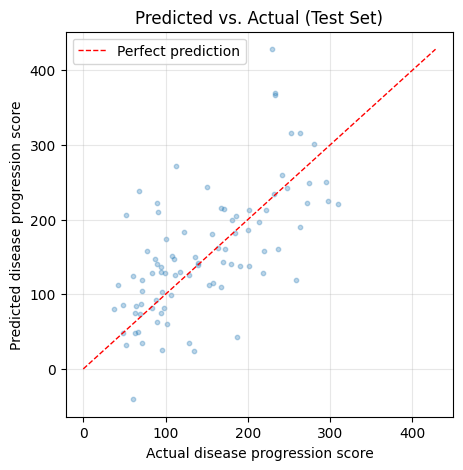

In [11]:
plt.figure(figsize=(5, 5))
plt.scatter(test_actual, test_preds, alpha=0.3, s=10)
lims = [0, max(test_actual.max(), test_preds.max())]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="Perfect prediction")
plt.xlabel("Actual disease progression score")
plt.ylabel("Predicted disease progression score")
plt.title("Predicted vs. Actual (Test Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<h4 style="font-family: Times New Roman"><strong>9. Notes</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
A few things worth pointing out about this run:
</p>
<ul style="font-family:Times New Roman; font-size:15px">
    <li>The training loss is an <i>average over batches</i> for each epoch, not the loss on a single last
    batch the way the 100-epoch sample implementation printed it. With batch size 8 and roughly 16,500 training
    rows, one epoch is over 2,000 batches, so printing only the final batch's loss would be noisy and not very
    representative of how the epoch actually went.</li>
    <li>Scaling the target as well as the inputs is what keeps MSE in a small, comparable range during
    training. It is undone with <tt>inverse_transform</tt> only when reporting MAE/RMSE, so those numbers are
    in the original units ($100,000s) and easier to reason about.</li>
    <li>Two fully connected layers with a ReLU in between is technically already a (very small) neural network
    rather than pure linear regression. A single <tt>nn.Linear</tt> layer, as used in the sample implementation
    earlier, is the literal linear regression case; the extra layer here is what the task instructions ask
    for.</li>
</ul>